<a href="https://colab.research.google.com/github/padmashalivarsha-netizen/AI_INTERNSHIP_CODTECH/blob/main/style_transfer.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install torch torchvision pillow matplotlib

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving content.jpg to content (1).jpg
Saving style.jpg to style (1).jpg


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models
import torchvision.transforms as transforms
from PIL import Image
import matplotlib.pyplot as plt
# Device configuration
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using Device:", device)

Using Device: cpu


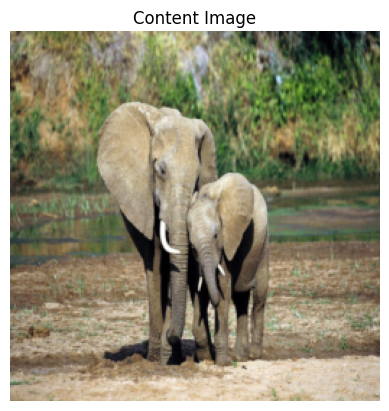

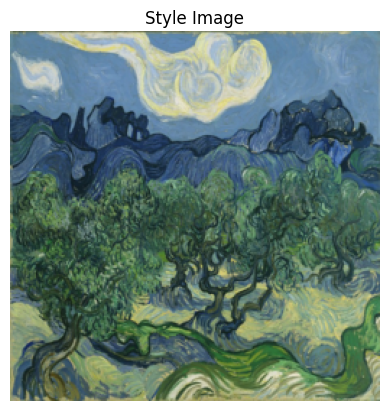

In [ ]:
def load_image(path, size=256):
  img = Image.open(path).convert("RGB")
  transform = transforms.Compose([
        transforms.Resize((size, size)),
        transforms.ToTensor()
  ])
  img = transform(img).unsqueeze(0)
  return img.to(device)
# Load content and style images
content = load_image("content.jpg")
style = load_image("style.jpg")
# Display content image
plt.imshow(content.cpu().squeeze(0).permute(1,2,0))
plt.title("Content Image")
plt.axis("off")
plt.show()
# Display style image
plt.imshow(style.cpu().squeeze(0).permute(1,2,0))
plt.title("Style Image")
plt.axis("off")
plt.show()

In [ ]:
vgg = models.vgg19(pretrained=True).features.to(device).eval()
# Freeze parameters
for param in vgg.parameters():
    param.requires_grad = False

In [ ]:
class Features(nn.Module):
    def __init__(self):
        super().__init__()
        self.model = vgg
    def forward(self, x):

        features = []

        layers = ['0', '5', '10', '19', '28']

        for name, layer in self.model._modules.items():

            x = layer(x)

            if name in layers:
                features.append(x)

        return features

# Initialize feature model
model = Features()

# Gram matrix function
def gram_matrix(x):

    _, c, h, w = x.size()

    x = x.view(c, h * w)

    return torch.mm(x, x.t())

# Create generated image
generated = content.clone().requires_grad_(True)

# Optimizer
optimizer = torch.optim.Adam([generated], lr=0.02)

# Weights
content_weight = 1
style_weight = 1e6


In [ ]:
epochs = 25

for i in range(epochs):

    content_features = model(content)
    style_features = model(style)
    gen_features = model(generated)
    # Content loss
    content_loss = torch.mean(
        (gen_features[-1] - content_features[-1]) ** 2
    )

    # Style loss
    style_loss = 0

    for gf, sf in zip(gen_features, style_features):

        style_loss += torch.mean(
            (gram_matrix(gf) - gram_matrix(sf)) ** 2
        )

    # Total loss
    loss = content_weight * content_loss + style_weight * style_loss

    optimizer.zero_grad()

    loss.backward()

    optimizer.step()

    # Print progress
    if i % 5 == 0:
        print(f"Epoch {i}, Loss: {loss.item():.4f}")


Epoch 0, Loss: 4780745818112.0000
Epoch 5, Loss: 1338832191488.0000
Epoch 10, Loss: 813270630400.0000
Epoch 15, Loss: 568062115840.0000
Epoch 20, Loss: 443242840064.0000


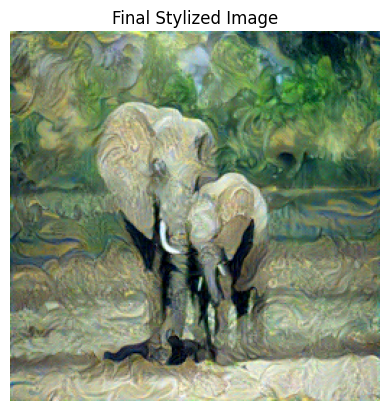

Style transfer completed successfully!
Saved as stylized_output.jpg


In [ ]:
output = generated.detach().cpu().squeeze(0).permute(1, 2, 0)

output = output.clamp(0, 1)

# Display stylized image
plt.imshow(output)

plt.axis("off")

plt.title("Final Stylized Image")

plt.show()

# Save output image
plt.imsave("stylized_output.jpg", output.numpy())

print("Style transfer completed successfully!")

print("Saved as stylized_output.jpg")






